### Figure S20 (Assembly-based activity)

In [185]:
### load packages
import math
import glob

import matplotlib.pyplot as plt
import polars as pl
pl.Config.set_tbl_rows(10)
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [2]:
### load coverm results to identify viruses detected in bulk and enriched
df_lst = []

for file in glob.glob('activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/coverm/*/*.coverm.tsv.gz'):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(file, separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'])
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.lit(group).alias('group')
            ])
            .with_columns([
                (pl.col('covered_bases')/pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)

In [3]:
### load unenriched vs uhvdb blast results
unenriched_v_uhvdb = pl.read_csv('activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/vclust_new2all/new_mq_plus_viruses/new_mq_plus_viruses.ani.tsv', separator='\t')

vclust_sample_lst = []
for sample in list(set(coverm_df['sample_id'])):
    df = unenriched_v_uhvdb.filter(pl.col('query').str.contains(sample))
    uhvdb_hits_in_sample = set(coverm_df.filter(pl.col('sample_id') == sample)['contig_id'])
    vclust_sample_lst.append(
        df.filter(pl.col('reference').is_in(uhvdb_hits_in_sample))
            .sort('gani', descending=True)
            .unique('query', maintain_order=True)
            .with_columns([pl.lit(sample).alias('sample_id')])
            .filter(pl.col('gani') >= 0.0)
    )
unenriched_v_uhvdb_vclust = pl.concat(vclust_sample_lst)

In [4]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('genomovar_rep')
)

In [5]:
# load checkv results for unenriched 
checkv_lst = []
for file in glob.glob('activity_profiling/liang_enriched_results/2026-04-03_outputs/classify/new_mq_plus_classify.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            [['seq_name', 'topology', 'provirus', 'completeness', 'completeness_method']]
    )
    checkv_lst.append(df)

checkv_df = (
    pl.concat(checkv_lst)
        .group_by('seq_name')
        .agg([
            ((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR'))).sum().alias('circular_count'),
            (pl.col('completeness').max()).alias('max_completeness'),
        ])
)


# load propagate results for unenriched
propagate_lst = []
for file in glob.glob('activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/propagate/liang_*unenriched/liang_*unenriched.propagate.tsv.gz'):
    # skip if empty df
    try:
        df = (
            pl.read_csv(file, separator='\t', null_values=['NA'], columns=['prophage', 'prophage_len', 'host', 'CohenD', 'host_len', 'prophage-host_ratio'])
                .with_columns([
                    pl.col('prophage').cast(pl.String),
                    pl.col('host').cast(pl.String),
                    pl.col('prophage_len').cast(pl.Int64),
                    pl.col('CohenD').cast(pl.Float64),
                    pl.col('prophage-host_ratio').cast(pl.Float64),
                    pl.col('prophage').str.split('_k').list[0].alias('sample_id')
                ])
        )
        propagate_lst.append(df)
    except:
        pass

propagate_df = (
    pl.concat(propagate_lst)
        .filter(pl.col('prophage-host_ratio') > 1)
)


# identify mvirs active viruses in unenriched
!zcat activity_profiling/liang_enriched_results/2026-04-03_outputs/assemblyanalyze/mvirs/liang_*unenriched/liang_*unenriched.mvirs.fasta.gz | \
    grep "^>" > unenriched_mvirs_contig_ids.txt

mvirs_contigs = (
    pl.read_csv('unenriched_mvirs_contig_ids.txt', separator=' ', has_header=False, new_columns=['mvirs_id'])
        .with_columns([
            pl.col('mvirs_id').str.replace('>', '').str.split(':').list[0].alias('contig_id_no_prophage'),
            pl.col('mvirs_id').str.split('OPRs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_oprs'),
            pl.col('mvirs_id').str.split('HSs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_clipped'),
        ])
        .with_columns([
            pl.col('contig_id_no_prophage').str.split('_k').list[0].alias('sample_id')
        ])
)

In [6]:
# combine all data together
enrich_v_unenrich = (
    coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']]
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']].filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .unique(['contig_id', 'sample_id'])
        .join(combined, left_on='contig_id', right_on='genomovar_rep', how='left')
        .fill_null(0.00)
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
        .join(unenriched_v_uhvdb_vclust[['query', 'reference', 'gani', 'sample_id']], left_on=['contig_id', 'sample_id'], right_on=['reference', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='seq_name', how='left')
        .join(propagate_df, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(mvirs_contigs[['contig_id_no_prophage', 'num_oprs', 'num_clipped', 'sample_id']], on=['contig_id_no_prophage', 'sample_id'], how='left')
        .with_columns([
            (pl.col('num_oprs') + pl.col('num_clipped')).alias('mvirs_count'),
        ])
        .group_by(['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'breadth_enriched', 'breadth_ratio_enriched', 'trimmed_mean_enriched', 'pr_cat'])
        .agg(
            pl.col('contig_id_no_prophage').first(),
            pl.col('mvirs_count').max(),
            pl.col('CohenD').max(),
            pl.col('circular_count').max(),
            pl.col('max_completeness').max(),
            pl.col('gani').max()
        )
)

In [7]:
print("Number of true positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false negatives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6)).height)

Number of true positives: 859
Number of false negatives: 22
Number of false positives: 1983


50


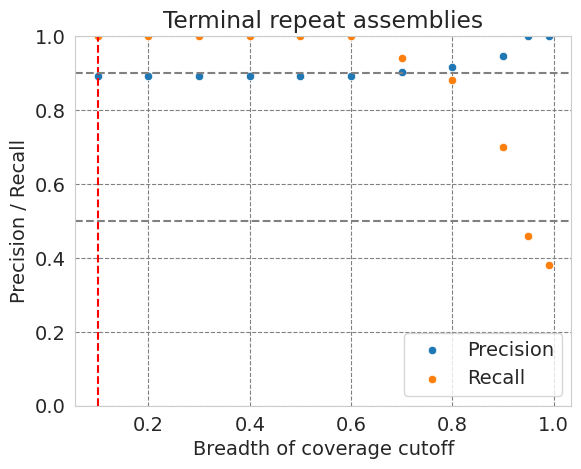

In [186]:
### Assembly DTR
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter(pl.col('circular_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axvline(x=0.1, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of coverage cutoff')
plt.ylabel('Precision / Recall')
plt.title('Terminal repeat assemblies')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

121


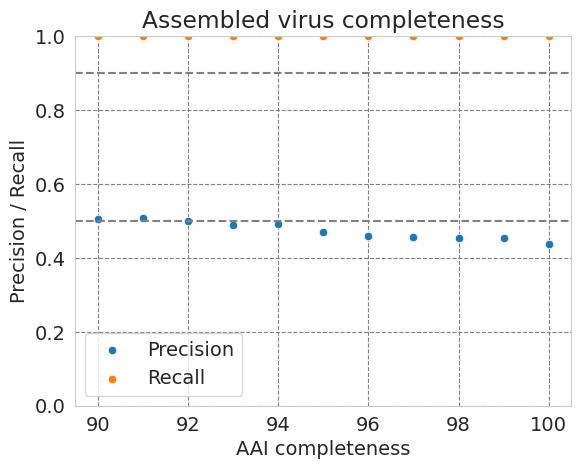

In [187]:
### Assembly AAI completeness
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('max_completeness') >= 90).filter(pl.col('circular_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100 ]:
    if (enrich_v_unenrich
            # .filter(pl.col('breadth_ratio') >= i)
            .filter(pl.col('max_completeness') >= i).filter(pl.col('circular_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('max_completeness') >= i).filter(pl.col('circular_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('max_completeness') >= i).filter(pl.col('circular_count') == 0)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('max_completeness') >= i).filter(pl.col('circular_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('max_completeness') >= i).filter(pl.col('circular_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100 ],
    y=recall_values
)
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('AAI completeness')
plt.ylabel('Precision / Recall')
plt.title('Assembled virus completeness')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [188]:
# check if megahit flag=1 with high cov is a signal of completeness
!zgrep "^>" \
    activity_profiling/results/uhvdb/assemble/prjna524703/liang_*/liang_*enriched/megahit/liang_*enriched.contigs.fa.gz \
    > megahit_contig_ids.txt

In [189]:
megahit_ids = (
    pl.read_csv('megahit_contig_ids.txt', separator=' ', new_columns=['contig_id', 'flag', 'multi', 'len'])
        .with_columns([
            pl.col('contig_id').str.replace_all(r'^.*>', ''),
            pl.col('multi').str.replace_all('multi=', '').cast(pl.Float64),
            pl.col('len').str.replace_all('len=', '').cast(pl.Int64)
        ])
)
enrich_v_unenrich = enrich_v_unenrich.join(megahit_ids, left_on='contig_id_no_prophage', right_on='contig_id', how='left')

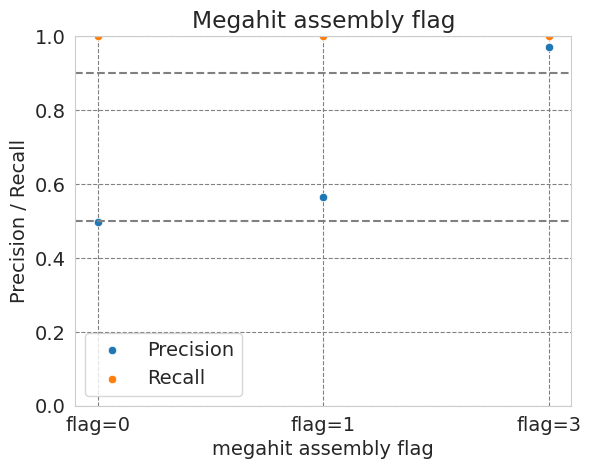

In [190]:
### megahit flag
precision_values = []
recall_values = []

for i in [ 'flag=0', 'flag=1', 'flag=3' ]:
    if (enrich_v_unenrich
            .filter(pl.col('flag') == i).filter(pl.col('multi') > 20)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('flag') == i).filter(pl.col('multi') > 20)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('flag') == i).filter(pl.col('multi') > 20)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('flag') == i).filter(pl.col('multi') > 20)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('flag') == i).filter(pl.col('multi') > 20)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 'flag=0', 'flag=1', 'flag=3'],
    y=precision_values
)
sns.scatterplot(
    x=['flag=0', 'flag=1', 'flag=3'],
    y=recall_values
)
# plt.axvline(x=90, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('megahit assembly flag')
plt.ylabel('Precision / Recall')
plt.title('Megahit assembly flag')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

27


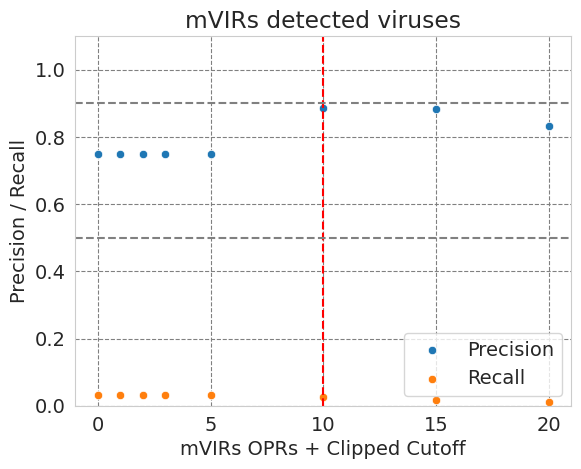

In [191]:
### mVIRs
precision_values = []
recall_values = []
tani = 0.6
print(enrich_v_unenrich
            .filter((pl.col('mvirs_count')) > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [0,1,2,3,5,10,15,20]:
    if (enrich_v_unenrich
            .filter((pl.col('mvirs_count')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter((pl.col('mvirs_count')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('mvirs_count')) >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter((pl.col('mvirs_count')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0,1,2,3,5,10,15,20],
    y=precision_values
)
sns.scatterplot(
    x=[0,1,2,3,5,10,15,20],
    y=recall_values
)
plt.axvline(x=10, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.xlabel('mVIRs OPRs + Clipped Cutoff')
plt.ylabel('Precision / Recall')
plt.title('mVIRs detected viruses')
plt.legend(labels=['Precision', 'Recall'])
plt.ylim(0, 1.1)
plt.show()

53


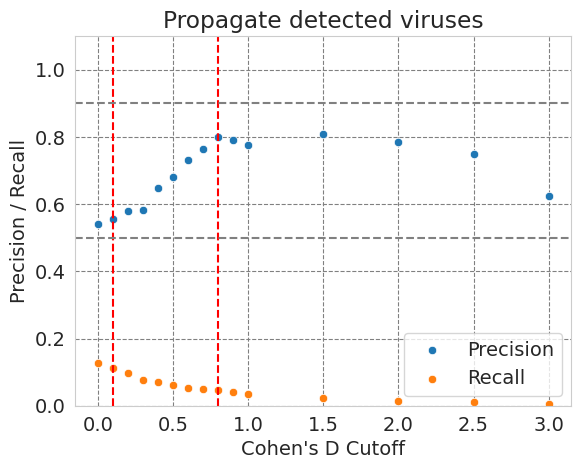

In [192]:
### propagate
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('CohenD') > 0.5)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter((pl.col('CohenD')) >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5],
    y=precision_values
)
sns.scatterplot(
    x=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0, 2.5, 3, 4, 5],
    y=recall_values
)
plt.axvline(x=0.1, color='red', linestyle='--')
plt.axvline(x=0.8, color='red', linestyle='--')
# plt.axvline(x=0.95, color='red', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Cohen\'s D Cutoff')
plt.ylabel('Precision / Recall')
plt.title('Propagate detected viruses')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [193]:
### load UHVDB species rep info
uhvdb_info = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_info.tsv.gz', separator='\t')
    .filter(pl.col('uhvdb_id') == pl.col('votu_rep'))
    .unique(pl.col('uhvdb_id'))
)

lifestyle_df = (
    pl.read_csv('../figure_3/uhvdb_v4_lifestyle.tsv', separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .with_columns([
            pl.when(
                (pl.col('topology') == 'Provirus') |
                (pl.col('provirus') == 'Yes') |
                (pl.col('temperate') > 0.5) |
                (pl.col('phrog_integrases') > 0) |
                (pl.col('phrog_integration_excision') > 0)
            )
            .then(pl.lit('hc_temperate'))
            .when(
                (pl.col('topology') == 'Provirus') |
                (pl.col('provirus') == 'Yes') |
                (pl.col('temperate') > 0.5) |
                (pl.col('phrog_integrases') > 0) |
                (pl.col('phrog_integration_excision') > 0)
                | (pl.col('empathi_integration') > 0)
            )
            .then(pl.lit('lc_temperate'))
            .otherwise(pl.lit('virulent'))
            .alias('lifestyle'),
            (
                (pl.col('topology') == 'Provirus').fill_null(False).cast(pl.UInt8) +
                (pl.col('provirus') == 'Yes').fill_null(False).cast(pl.UInt8) +
                (pl.col('temperate') > 0.5).fill_null(False).cast(pl.UInt8) +
                (pl.col('phrog_integrases') > 0).fill_null(False).cast(pl.UInt8) +
                (pl.col('phrog_integration_excision') > 0).fill_null(False).cast(pl.UInt8) +
                (pl.col('empathi_integration') > 0).fill_null(False).cast(pl.UInt8)
            ).alias('temperate_signal_count')
        ])
        .group_by('votu_rep')
        .agg([
            # identify most prevalent lifestyle
            pl.col('lifestyle').value_counts(sort=True).first().struct.field('lifestyle').alias('lifestyle'),
            # identify counts of most prev lifestyle
            pl.col('lifestyle').value_counts(sort=True).first().struct.field('count').alias('lifestyle_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_count'),
            pl.col('temperate_signal_count').median().alias('temperate_signal_count'),
            pl.col('virulent').median().alias('bacphlip_virulent_score')
        ])
        .with_columns([
            (pl.col('lifestyle_count')/pl.col('total_count')).alias('lifestyle_proportion')
        ])
)

In [194]:
hqfilter_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_hqfilter.tsv.gz', ignore_errors=True, separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep',  'genus_cluster_id', 'family_cluster_id']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .unique('uhvdb_id')
        .sort('aai_completeness', descending=True)
        .unique('votu_rep', maintain_order=True)
)

classify_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_classify.tsv.gz', ignore_errors=True, separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .unique('uhvdb_id')
        .group_by('votu_rep')
        .agg([
            ((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR'))).sum().alias('circular_count'),
        ])
)

In [195]:
phage_host_ratio_lst = []

for file in glob.glob('sylph_tax_results/liang_*enriched.profileliang_*unenriched_R1.fastq.gz.sylphmpa'):
    sample_id=file.split('/')[-1].split('.profile')[0]
    df = pl.read_csv(file, separator='\t', skip_rows=1, new_columns=['clade_name', 'taxonomic_abundance', 'relative_abundance', 'ani', 'coverage', 'virus_host'], null_values=['NA'])
    virus_df = df.filter(pl.col('virus_host').is_not_null()).with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    phage_host_ratio_lst.append(
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep')
            ])
    )

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)

In [196]:
# combine all data together
active_families = set(
        combined
            .group_by('family_cluster_id')
            .agg([
                ((pl.col('checkv_quality') == 'Complete').sum() / pl.len()).alias('complete_ratio'),
                pl.len().alias('total_count')
            ])
            .filter(pl.col('total_count') >= 1)
            .filter(pl.col('complete_ratio') >= 0.3)
            ['family_cluster_id']
    )

ref_enrich_v_unenrich = (
    coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']]
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']].filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
        .join(lifestyle_df[['votu_rep', 'bacphlip_virulent_score']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(hqfilter_df[['votu_rep', 'aai_id', 'aai_af', 'family_cluster_id']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(classify_df[['votu_rep', 'circular_count']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(phage_host_ratio_df[['votu_rep', 'sample_id', 'phage_host_ratio']], left_on=['contig_id', 'sample_id'], right_on=['votu_rep', 'sample_id'], how='left')
        .unique(['contig_id', 'sample_id'])
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('breadth') >= 0.85) | (pl.col('breadth_ratio') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_breadth_score'),
            # reference evidence of activity
            pl.when((pl.col('circular_count') > 0) | (pl.col('family_cluster_id').is_in(active_families)) | ((pl.col('aai_id') * 0.01 *  pl.col('aai_af')) >= 80)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_tr_score'),
            pl.when((pl.col('bacphlip_virulent_score') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_virulent_score'),
            pl.when(pl.col('phage_host_ratio') >= 10).then(pl.lit(4.0))
                .when(pl.col('phage_host_ratio') >= 1.5).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_phage_host_ratio_score')
        ])
        .with_columns([
            (
                pl.col('ref_breadth_score') +
                pl.col('ref_tr_score') +
                pl.col('ref_virulent_score') +
                pl.col('ref_phage_host_ratio_score')
            ).alias('ref_activity_score')
        ])
        .fill_null(0.00)
)
enrich_v_unenrich.height

3682

In [197]:
# combine all data together
assem_enrich_v_unenrich = (
    coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']]
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']].filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .unique(['contig_id', 'sample_id'])
        .join(combined, left_on='contig_id', right_on='genomovar_rep', how='left')
        .fill_null(0.00)
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
        .join(unenriched_v_uhvdb_vclust[['query', 'reference', 'gani', 'sample_id']], left_on=['contig_id', 'sample_id'], right_on=['reference', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='seq_name', how='left')
        .join(propagate_df, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(mvirs_contigs[['contig_id_no_prophage', 'num_oprs', 'num_clipped', 'sample_id']], on=['contig_id_no_prophage', 'sample_id'], how='left')
        .with_columns([
            (pl.col('num_oprs') + pl.col('num_clipped')).alias('mvirs_count'),
        ])
        .group_by(['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'breadth_enriched', 'breadth_ratio_enriched', 'trimmed_mean_enriched', 'pr_cat'])
        .agg(
            pl.col('contig_id_no_prophage').first(),
            pl.col('mvirs_count').max(),
            pl.col('CohenD').max(),
            pl.col('circular_count').max()
        )
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('circular_count') > 0)).then(pl.lit(4.0))
                .otherwise(pl.lit(0.0)).alias('assem_tr_score'),
            # reference evidence of activity
            pl.when(pl.col('mvirs_count') >= 10).then(pl.lit(3.0))
                .when(pl.col('mvirs_count') >= 1).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('assem_mvirs_score'),
            pl.when((pl.col('CohenD') >= 0.8)).then(pl.lit(2.0))
                .when((pl.col('CohenD') >= 0.1)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('assem_propagate_score')
        ])
        .with_columns([
            (
                pl.col('assem_tr_score') +
                pl.col('assem_mvirs_score') +
                pl.col('assem_propagate_score')
            ).alias('assem_activity_score')
        ])
        .fill_null(0.00)
)
assem_enrich_v_unenrich.height

3682

In [198]:
enrich_v_unenrich_final = (
    ref_enrich_v_unenrich
        .join(assem_enrich_v_unenrich, on=['contig_id', 'sample_id'], how='inner')
        .with_columns((pl.col('ref_activity_score') + pl.col('assem_activity_score')).alias('activity_score'))
)
enrich_v_unenrich_final.height

3681

In [199]:
(
    enrich_v_unenrich_final
        .with_columns([
            (pl.col('ref_breadth_score') > 0).sum().alias('num_ref_breadth_score'),
            (pl.col('ref_tr_score') > 0).sum().alias('num_ref_tr_score'),
            (pl.col('ref_virulent_score') > 0).sum().alias('num_ref_virulent_score'),
            (pl.col('ref_phage_host_ratio_score') > 0).sum().alias('num_ref_phage_host_ratio_score'),
            (pl.col('assem_tr_score') > 0).sum().alias('num_assem_tr_score'),
            (pl.col('assem_mvirs_score') > 0).sum().alias('num_assem_mvirs_score'),
            (pl.col('assem_propagate_score') > 0).sum().alias('num_assem_propagate_score'),
        ])
        [['num_ref_breadth_score', 'num_ref_tr_score', 'num_ref_virulent_score', 'num_ref_phage_host_ratio_score', 'num_assem_tr_score', 'num_assem_mvirs_score', 'num_assem_propagate_score']]
        .head(1)
)

num_ref_breadth_score,num_ref_tr_score,num_ref_virulent_score,num_ref_phage_host_ratio_score,num_assem_tr_score,num_assem_mvirs_score,num_assem_propagate_score
u32,u32,u32,u32,u32,u32,u32
858,1424,99,489,57,40,187


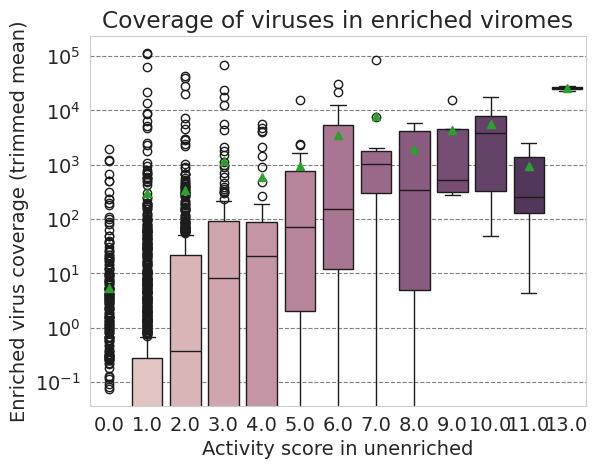

In [200]:
sns.boxplot(
    data=enrich_v_unenrich_final.filter((pl.col('trimmed_mean') > 0)),
    x='activity_score',
    y='trimmed_mean_enriched',
    hue='activity_score',
    showmeans=True
)
plt.yscale('log')
plt.xlabel('Activity score in unenriched')
plt.ylabel('Enriched virus coverage (trimmed mean)')
plt.title('Coverage of viruses in enriched viromes')
# hide legend
plt.legend().remove()
plt.show()

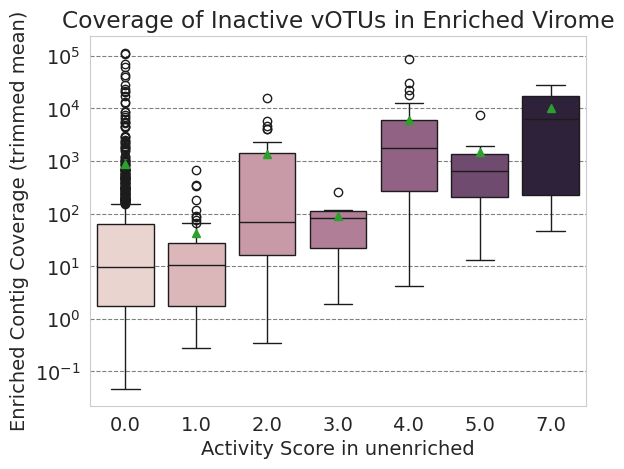

In [201]:
sns.boxplot(
    data=enrich_v_unenrich_final.filter((pl.col('trimmed_mean_enriched') > 0)),
    x='assem_activity_score',
    y='trimmed_mean_enriched',
    hue='assem_activity_score',
    showmeans=True
)
plt.yscale('log')
plt.xlabel('Activity Score in unenriched')
plt.ylabel('Enriched Contig Coverage (trimmed mean)')
plt.title('Coverage of Inactive vOTUs in Enriched Virome')
# hide legend
plt.legend().remove()
plt.show()

859


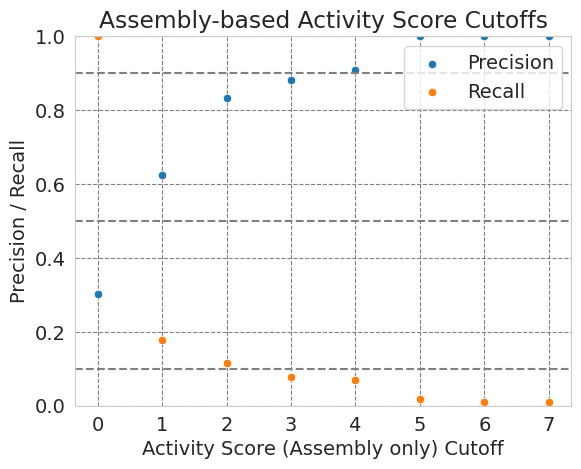

In [202]:
precision_values = []
recall_values = []
print(assem_enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    if (assem_enrich_v_unenrich
            .filter(pl.col('assem_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        assem_enrich_v_unenrich
            .filter(pl.col('assem_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        assem_enrich_v_unenrich
            .filter(pl.col('assem_activity_score') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        assem_enrich_v_unenrich
            .filter(pl.col('assem_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        assem_enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Activity Score (Assembly only) Cutoff')
plt.ylabel('Precision / Recall')
plt.title('Assembly-based Activity Score Cutoffs')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

859


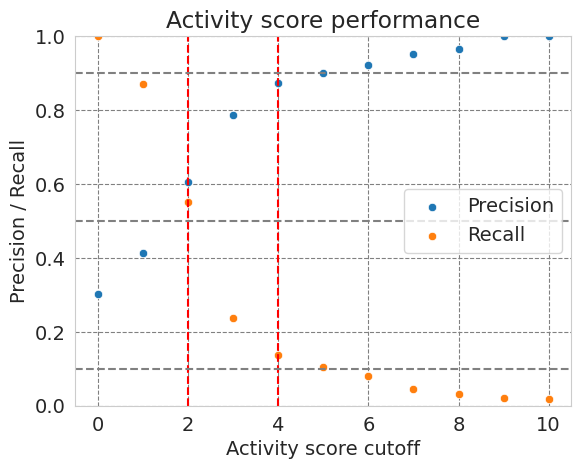

In [203]:
precision_values = []
recall_values = []
print(enrich_v_unenrich_final
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
)
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich_final
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    y=recall_values
)
plt.axvline(x=2, color='red', linestyle='--')
plt.axvline(x=4, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Activity score cutoff')
plt.ylabel('Precision / Recall')
plt.title('Activity score performance')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

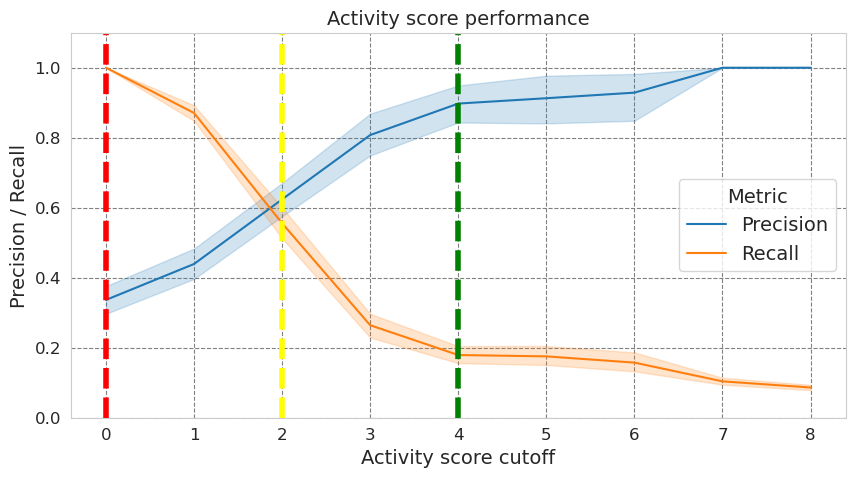

In [204]:
# Calculate precision and recall per group
results = []

for group_name in enrich_v_unenrich_final['group'].unique():
    group_data = enrich_v_unenrich_final.filter(pl.col('group') == group_name)
    
    for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        # Check if we have enough data points
        total_detected = group_data.filter(
            (pl.col('pr_cat')  == 'TP')
).height
        
        filtered_detected = group_data.filter(
            pl.col('activity_score') >= i
).filter(
            (pl.col('pr_cat') == 'TP')
).height
        
        filtered_total = group_data.filter(
            pl.col('activity_score') >= i
).filter(
            pl.col('breadth_ratio') >= 0.6
).height
        
        if filtered_detected >= 3 and filtered_total > 0:
            precision = filtered_detected / filtered_total
            results.append({'group': group_name, 'cutoff': i, 'metric': 'Precision', 'value': precision})
        
        if filtered_detected >= 3 and total_detected > 0:
            recall = filtered_detected / total_detected
            results.append({'group': group_name, 'cutoff': i, 'metric': 'Recall', 'value': recall})

# Convert to pandas DataFrame for seaborn
import pandas as pd
results_df = pd.DataFrame(results)

# Create lineplot with 95% CI
plt.figure(figsize=(10, 5))
ax = plt.gca()

sns.lineplot(
    data=results_df,
    x='cutoff',
    y='value',
    hue='metric',
    errorbar=('ci', 95)
)
# add horizontal grid
sns.set_style("whitegrid", {'grid.color': 'grey', 'grid.linestyle': '--'})
plt.ylim(0, 1.1)
plt.xlabel('Activity score cutoff')
plt.ylabel('Precision / Recall')
# increase font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Activity score performance', fontsize=14)
plt.legend(title='Metric')
plt.axvline(x=0, color='red', linestyle='--', linewidth=4)
plt.axvline(x=2, color='yellow', linestyle='--', linewidth=4)
plt.axvline(x=4, color='green', linestyle='--', linewidth=4)
plt.show()

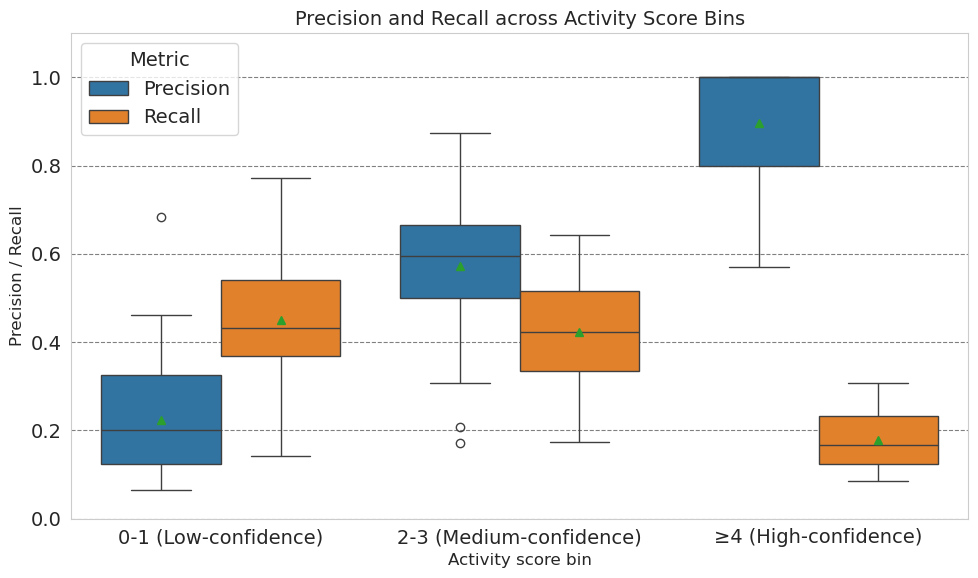

In [205]:
# Create boxplot of precision/recall across activity score bins
# Bin cutoffs are inclusive on the lower bound and exclusive on the upper bound:
# 0-1 -> [0, 2), 2-4 -> [2, 5), >=5 -> [5, inf)

import pandas as pd

results = []

bin_specs = [
    ('0-1 (Low-confidence)', 0, 2),
    ('2-3 (Medium-confidence)', 2, 4),
    ('≥4 (High-confidence)', 4, None),
]

for group_name in enrich_v_unenrich_final['group'].unique():
    group_data = enrich_v_unenrich_final.filter(pl.col('group') == group_name)
    total_detected = group_data.filter(pl.col('pr_cat') == 'TP').height

    for bin_name, activity_score, next_activity_score_bin in bin_specs:
        cutoff_expr = pl.col('activity_score') >= activity_score
        if next_activity_score_bin is not None:
            cutoff_expr = cutoff_expr & (pl.col('activity_score') < next_activity_score_bin)

        filtered_detected = (
            group_data
                .filter(cutoff_expr)
                .filter(pl.col('pr_cat') == 'TP')
                .height
        )

        filtered_total = (
            group_data
                .filter(cutoff_expr)
                .filter(pl.col('breadth_ratio') >= 0.6)
                .height
        )

        if filtered_detected >= 3 and filtered_total > 0:
            precision = filtered_detected / filtered_total
            results.append({
                'bin': bin_name,
                'metric': 'Precision',
                'value': precision,
                'group': group_name,
            })

        if filtered_detected >= 3 and total_detected > 0:
            recall = filtered_detected / total_detected
            results.append({
                'bin': bin_name,
                'metric': 'Recall',
                'value': recall,
                'group': group_name,
            })

bin_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=bin_df,
    x='bin',
    y='value',
    hue='metric',
    order=['0-1 (Low-confidence)', '2-3 (Medium-confidence)', '≥4 (High-confidence)'],
    showmeans=True,
)
plt.xlabel('Activity score bin', fontsize=12)
plt.ylabel('Precision / Recall', fontsize=12)
plt.title('Precision and Recall across Activity Score Bins', fontsize=14)

plt.ylim(0, 1.1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [216]:
results_df[(results_df['cutoff'] == 0) & (results_df['metric'] == 'Precision')]['value'].mean()

np.float64(0.33663209977754943)

In [215]:
results_df[(results_df['cutoff'] == 4) & (results_df['metric'] == 'Recall')]['value'].mean()

np.float64(0.17914533954297687)

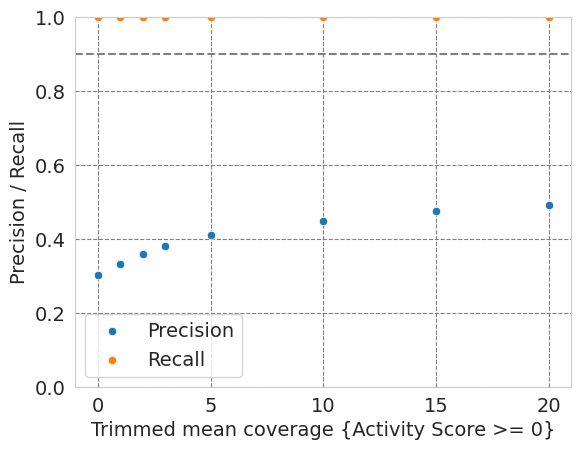

In [208]:
precision_values = []
recall_values = []
activity_score = 0

for i in [0, 1, 2, 3, 5, 10, 15, 20]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Trimmed mean coverage {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

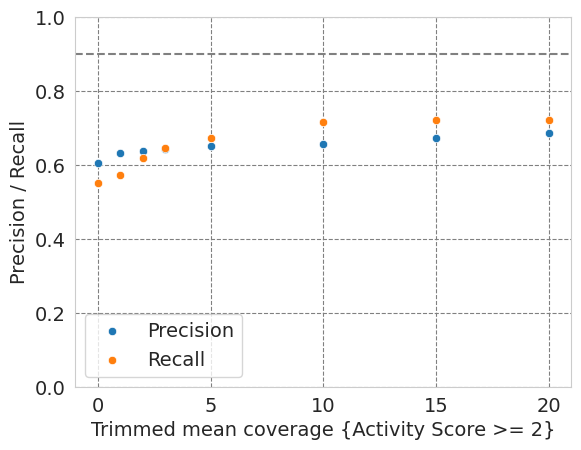

In [209]:
precision_values = []
recall_values = []
activity_score = 2

for i in [0, 1, 2, 3, 5, 10, 15, 20]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched')  >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Trimmed mean coverage {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

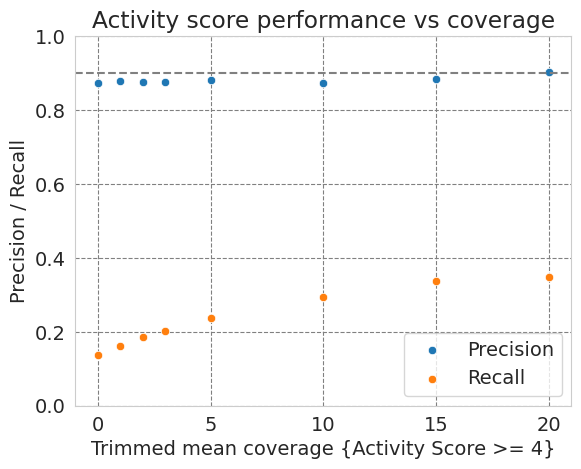

In [210]:
precision_values = []
recall_values = []
activity_score = 4

for i in [0, 1, 2, 3, 5, 10, 15, 20]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('trimmed_mean') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 5, 10, 15, 20],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Trimmed mean coverage {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('Activity score performance vs coverage')
plt.show()

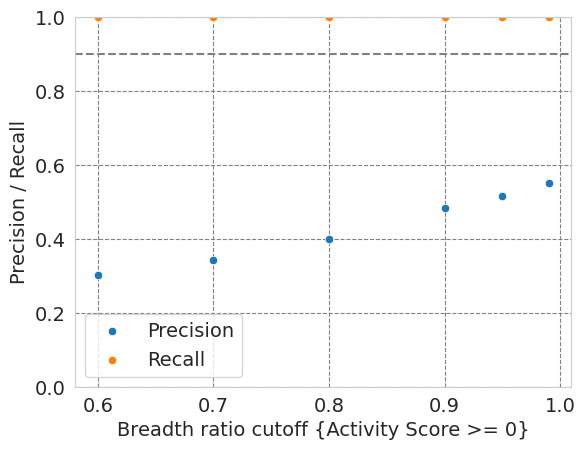

In [211]:
precision_values = []
recall_values = []
activity_score = 0

for i in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99 ]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth ratio cutoff {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

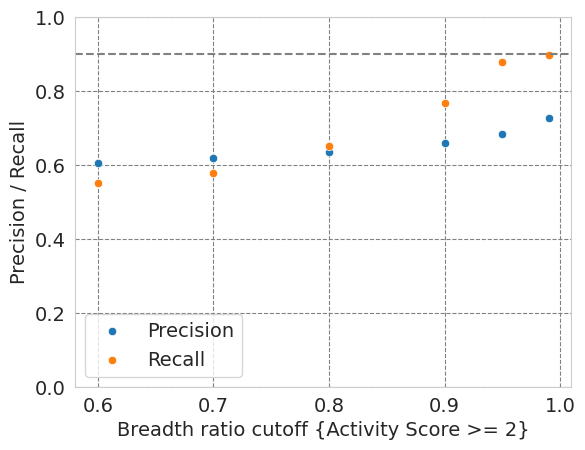

In [212]:
precision_values = []
recall_values = []
activity_score = 2

for i in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99 ]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth ratio cutoff {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

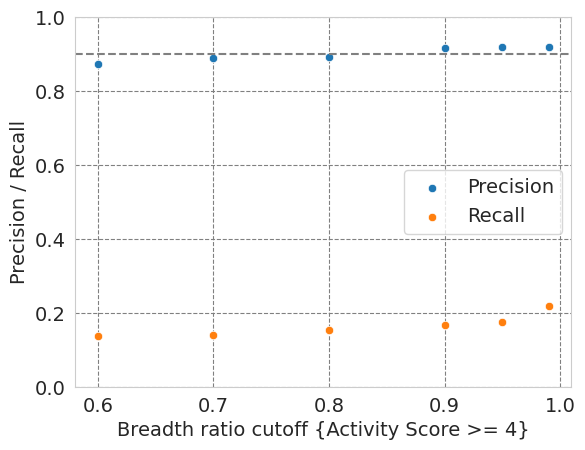

In [213]:
precision_values = []
recall_values = []
activity_score = 4

for i in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99 ]:
    if (enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich_final
            .filter(pl.col('activity_score') >= activity_score)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
        /
        enrich_v_unenrich_final
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('breadth_ratio_enriched') >= 0.6) & (pl.col('breadth_ratio') >= 0.6))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='grey', linestyle='--')
# plt.axhline(y=0.1, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth ratio cutoff {Activity Score >= %d}' % activity_score)
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.show()